Figures will be saved to: .

  30 tickers, 2554 trading days.

  30 tickers, 337 trading days.

  30 tickers, 1302 trading days.

Benchmark (XU030.IS) downloaded successfully.

Estimation window : 2015-01-01 - 2024-12-31
Valid tickers     : 30
Risk-free rate    : 18% (annualised, time-weighted avg)

Simulating 50,000 random portfolios (10% cap)...

Monte Carlo simulation complete.

Running QP optimisation (10% weight cap)...

  'Max Sharpe' converged successfully.
  'Min Variance' converged successfully.
  'Max Sortino' converged successfully.

QP optimisation complete.



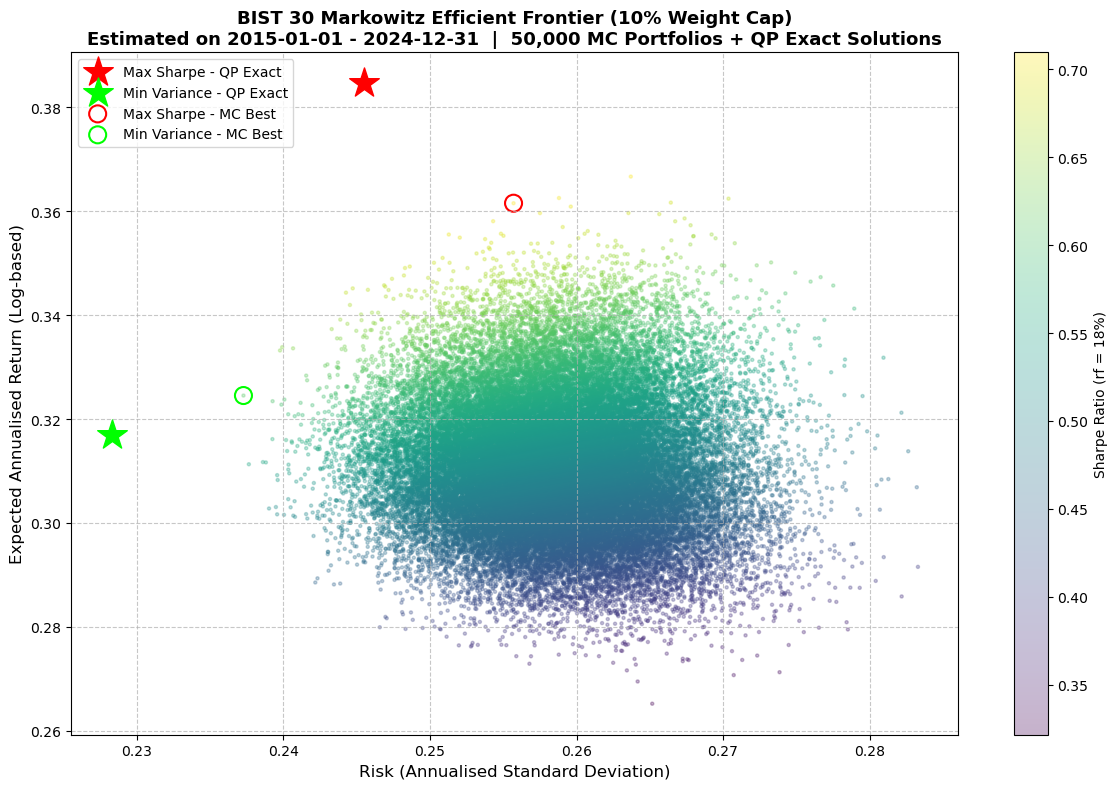

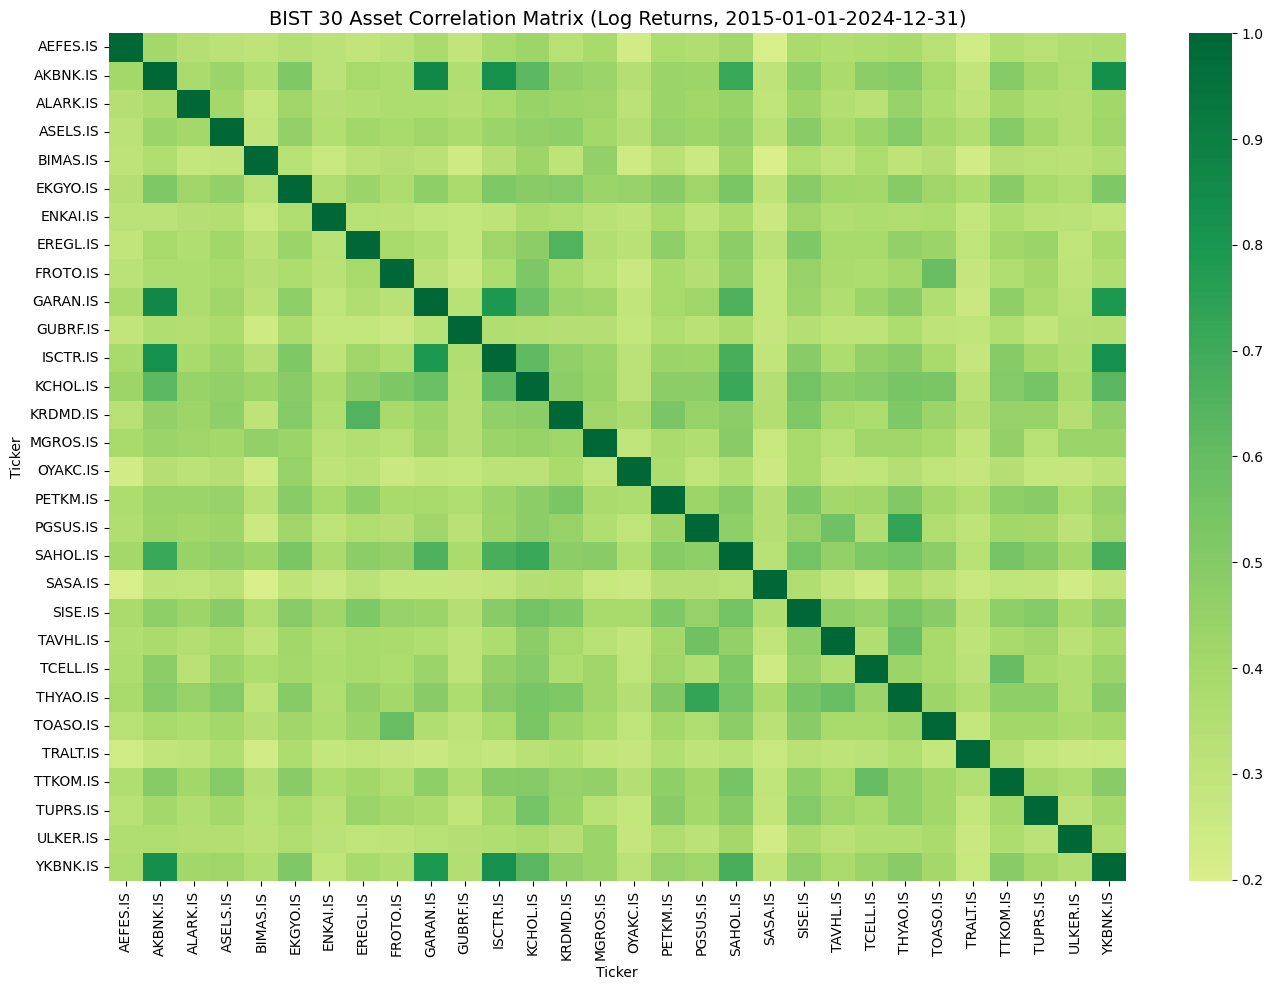

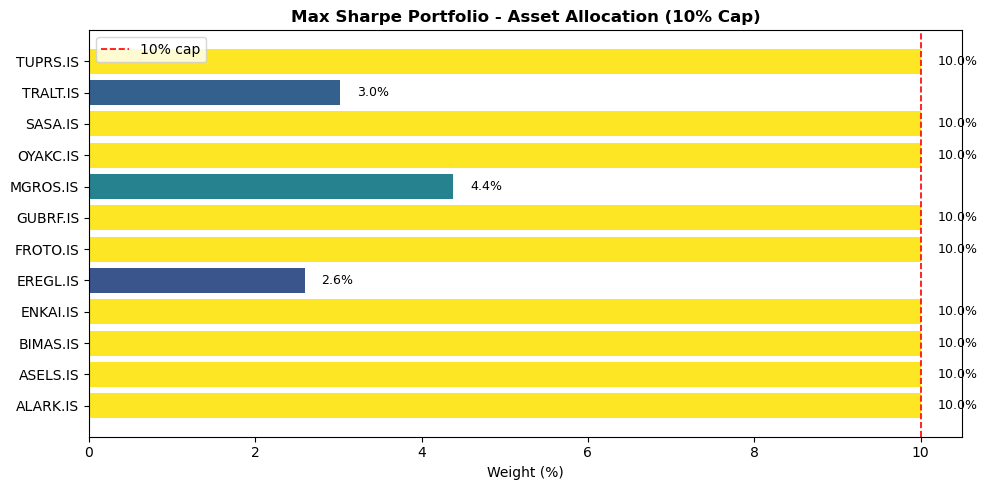


  MAX SHARPE PORTFOLIO - QP Exact (10% cap)
      Ticker  Weight (%)
1   ALARK.IS   10.000000
2   ASELS.IS   10.000000
3   BIMAS.IS   10.000000
4   ENKAI.IS   10.000000
5   FROTO.IS   10.000000
6   OYAKC.IS   10.000000
7   TUPRS.IS   10.000000
8   GUBRF.IS   10.000000
9    SASA.IS   10.000000
10  MGROS.IS    4.382933
11  TRALT.IS    3.022518
12  EREGL.IS    2.594549
  Total allocated         : 100.00%
  Expected annual return  : 38.46%
  Annual std deviation    : 24.55%
  Sharpe  ratio (rf=18%) : 0.8333
  Sortino ratio (rf=18%) : 1.1626


  MIN VARIANCE PORTFOLIO - QP Exact (10% cap)
      Ticker  Weight (%)
1   OYAKC.IS   10.000000
2   TUPRS.IS   10.000000
3   BIMAS.IS   10.000000
4   ENKAI.IS   10.000000
5   TCELL.IS   10.000000
6   AEFES.IS   10.000000
7   EREGL.IS    8.804527
8   ULKER.IS    6.561193
9   FROTO.IS    6.104671
10  MGROS.IS    5.012577
11  ALARK.IS    3.542123
12  TAVHL.IS    2.249054
13  GARAN.IS    1.907334
14   SASA.IS    1.867770
15  GUBRF.IS    1.652479
16  TRAL

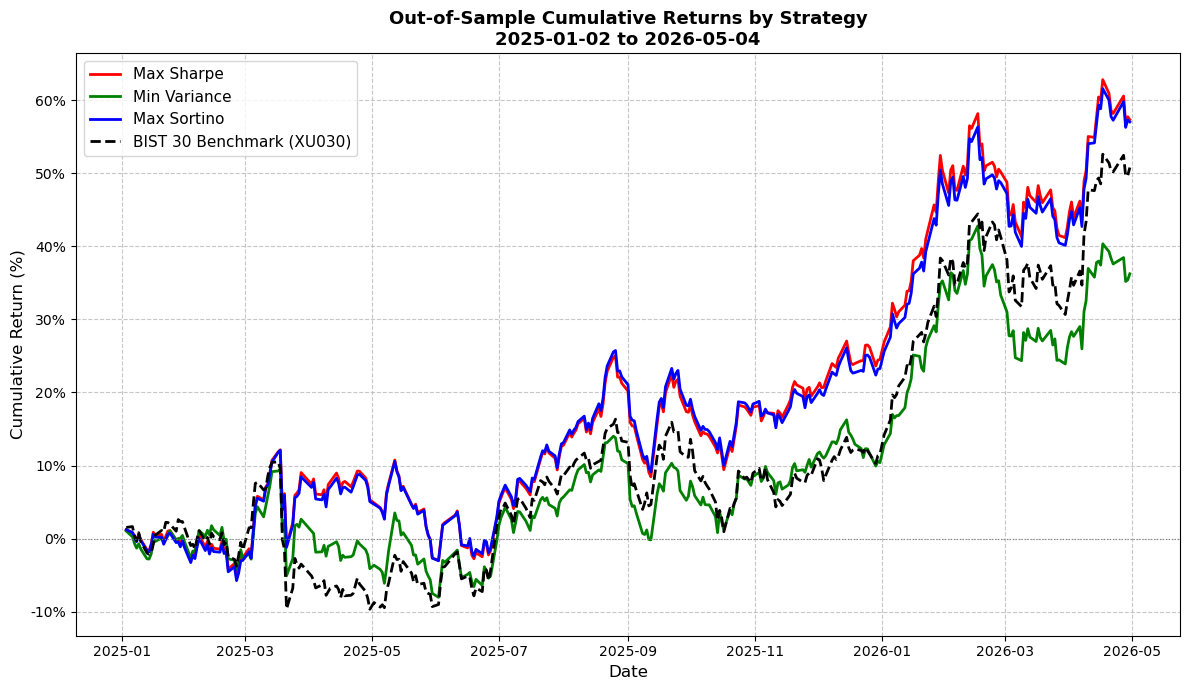


  STEP 2: COVID ROBUSTNESS CHECK
  Pre-COVID (2015-2019) vs Full Window (2015-2024)

  [Pre-COVID 2015-2019] optimisation complete.
  [Full Window 2015-2024] optimisation complete.


── Max Sharpe ──
  Ticker  Pre-COVID (%)  Full Window (%)  Diff (pp)
ALARK.IS          10.00            10.00       0.00
ASELS.IS          10.00            10.00       0.00
BIMAS.IS          10.00            10.00       0.00
ENKAI.IS           1.63            10.00       8.37
FROTO.IS          10.00            10.00       0.00
GUBRF.IS           0.00            10.00      10.00
OYAKC.IS           8.37            10.00       1.63
 SASA.IS          10.00            10.00       0.00
TUPRS.IS          10.00            10.00       0.00
MGROS.IS           0.00             4.38       4.38
TRALT.IS          10.00             3.02      -6.98
EREGL.IS          10.00             2.59      -7.41
PETKM.IS          10.00             0.00     -10.00

── Min Variance ──
  Ticker  Pre-COVID (%)  Full Window (%)  Diff (pp)

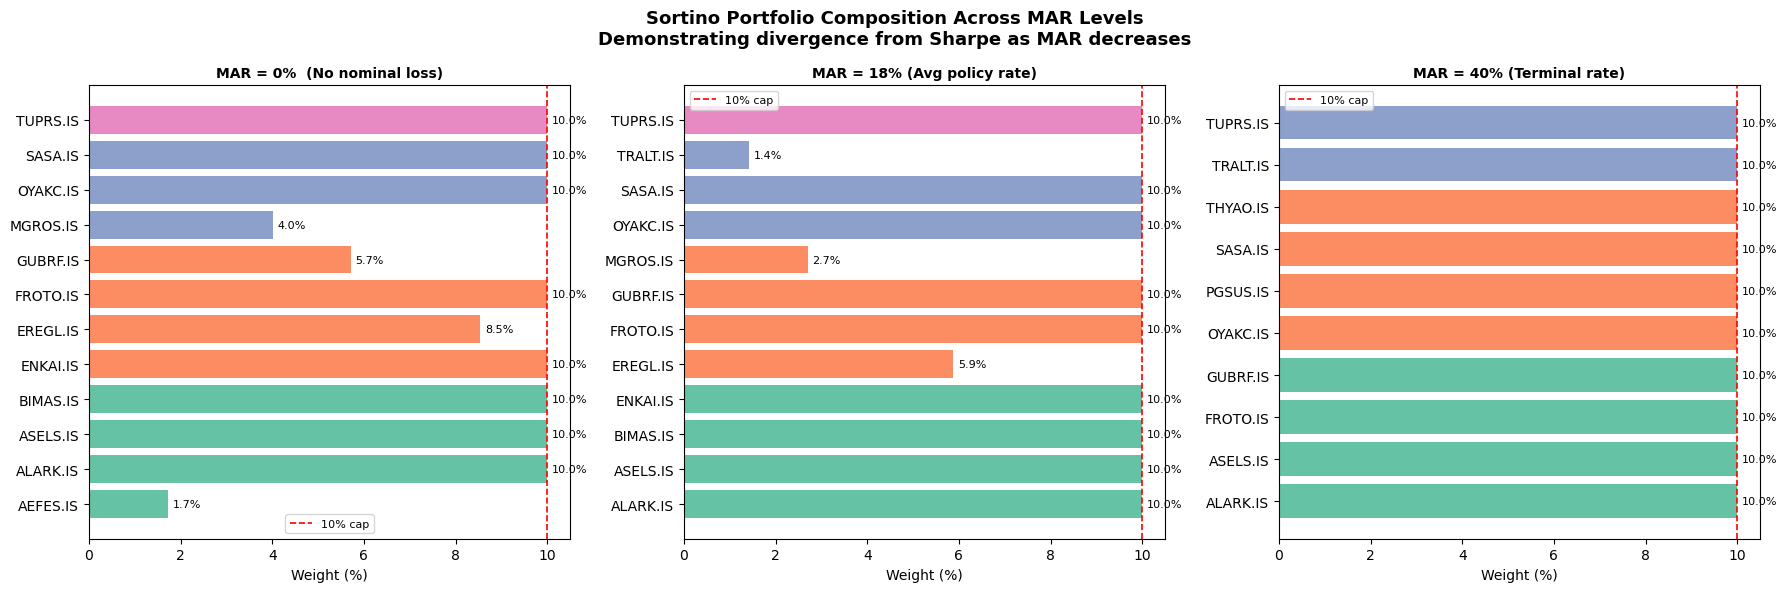


  STEP 4: ESTIMATION ERROR SENSITIVITY ANALYSIS
  500 perturbations at ±1 Standard Error of Mean Return

  Perturbation 100/500 complete...
  Perturbation 200/500 complete...
  Perturbation 300/500 complete...
  Perturbation 400/500 complete...
  Perturbation 500/500 complete...

── Max Sharpe: Weight stability under return perturbation ──
  Ticker  Base Weight %  Mean Perturbed %  Std Dev %  95% CI Lower  95% CI Upper
ALARK.IS          10.00             10.00       0.00         10.00         10.00
ASELS.IS          10.00             10.00       0.00         10.00         10.00
BIMAS.IS          10.00             10.00       0.00         10.00         10.00
ENKAI.IS          10.00              9.42       1.08          7.31         11.53
FROTO.IS          10.00             10.00       0.00         10.00         10.00
GUBRF.IS          10.00              9.97       0.23          9.51         10.42
OYAKC.IS          10.00              9.99       0.08          9.83         10.16
 SASA.IS 

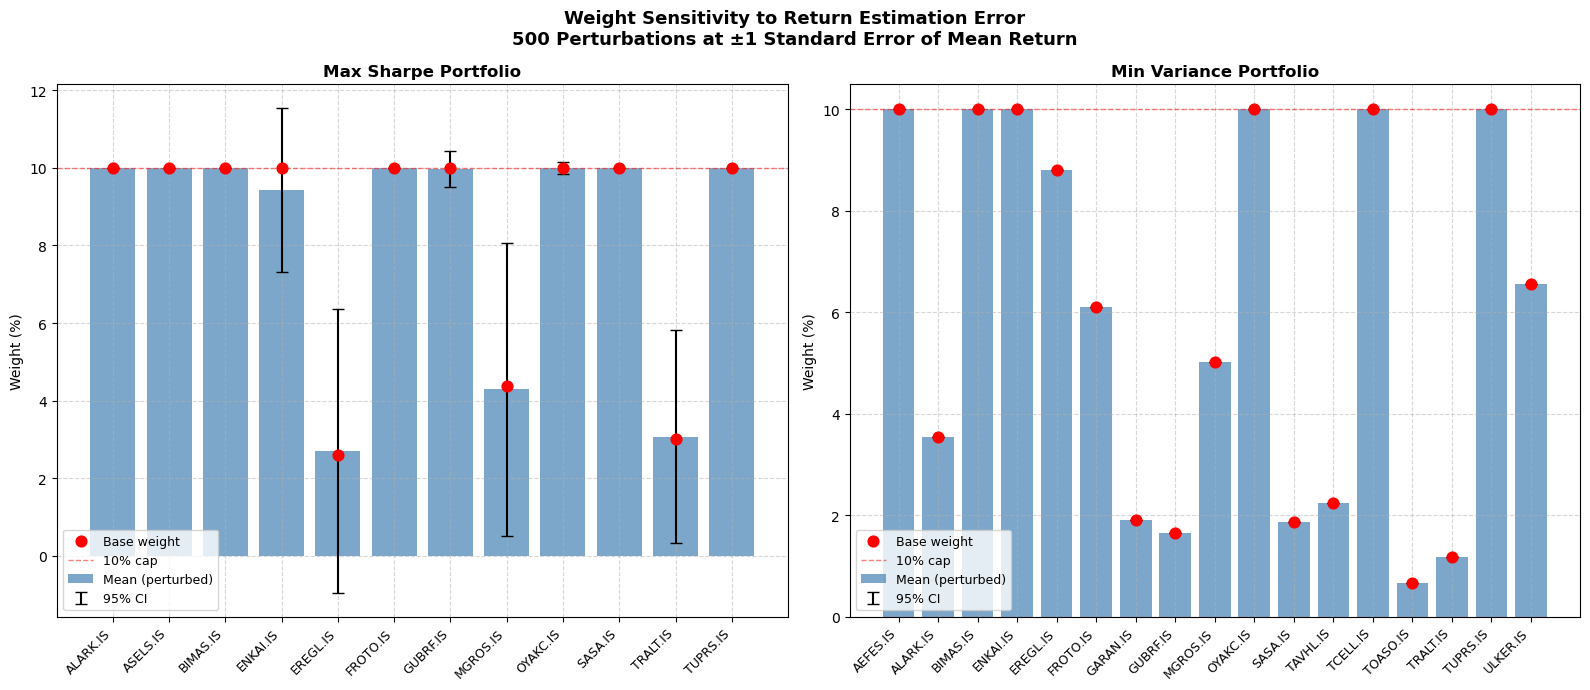


  All figures saved to: .
  - efficient_frontier_final.png
  - correlation_heatmap_final.png
  - weight_distribution_final.png
  - cumulative_returns.png
  - sortino_mar_divergence.png     
  - sensitivity_analysis.png        


In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import minimize
import os

OUTPUT_DIR = "."
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Figures will be saved to: {OUTPUT_DIR}\n")

np.random.seed(42)

# ── Date Windows ──────────────────────────────────────────────────────────────
TRAIN_START    = "2015-01-01"
TRAIN_END      = "2024-12-31"
TEST_START     = "2025-01-01"
TEST_END       = "2026-05-05"
PRE_COVID_START = "2015-01-01"
PRE_COVID_END   = "2019-12-31"

bist30_tickers = [
    'AKBNK.IS', 'ASELS.IS', 'BIMAS.IS', 'EKGYO.IS', 'ENKAI.IS',
    'EREGL.IS', 'FROTO.IS', 'GARAN.IS', 'GUBRF.IS', 'TRALT.IS',
    'ISCTR.IS', 'KCHOL.IS', 'AEFES.IS', 'MGROS.IS', 'KRDMD.IS',
    'PGSUS.IS', 'SAHOL.IS', 'SASA.IS', 'SISE.IS', 'TAVHL.IS',
    'TCELL.IS', 'THYAO.IS',  'TOASO.IS', 'ULKER.IS', 'OYAKC.IS',
    'TTKOM.IS', 'TUPRS.IS', 'YKBNK.IS', 'PETKM.IS', 'ALARK.IS',
]

BENCHMARK_TICKER = 'XU030.IS'

# ── STEP 1: Historically accurate, period-specific risk-free rates ─────────────
trading_days         = 252
risk_free_rate_train = 0.18   # time-weighted avg TCMB repo, 2015-2024
risk_free_rate_test  = 0.44   # time-weighted avg TCMB repo, 2025-2026
risk_free_rate       = risk_free_rate_train   # used for all in-sample optimization
MAR_daily            = risk_free_rate / trading_days

# ── Data Download ─────────────────────────────────────────────────────────────
def _get_prices(tickers, start, end, label):
    print(f"Downloading {label} data ({start} -> {end})...")
    raw = yf.download(tickers, start=start, end=end, progress=False)
    if 'Adj Close' in raw:
        prices = raw['Adj Close']
    elif 'Close' in raw:
        prices = raw['Close']
        print(f"  Warning: 'Adj Close' not found for {label}; using 'Close'.")
    else:
        raise ValueError(f"No price data returned for {label}.")

    prices = prices.dropna(axis=1, how='all')
    if prices.empty or prices.shape[1] == 0:
        raise ValueError(
            f"No valid price data for {label}. "
            "Check internet connection and ticker symbols."
        )
    print(f"  {prices.shape[1]} tickers, {len(prices)} trading days.\n")
    return prices

train_prices     = _get_prices(bist30_tickers, TRAIN_START,     TRAIN_END,     "TRAIN")
test_prices      = _get_prices(bist30_tickers, TEST_START,      TEST_END,      "TEST")
pre_covid_prices = _get_prices(bist30_tickers, PRE_COVID_START, PRE_COVID_END, "PRE-COVID")

# Align all three windows to common tickers
common_tickers   = sorted(
    set(train_prices.columns) &
    set(test_prices.columns)  &
    set(pre_covid_prices.columns)
)
train_prices     = train_prices[common_tickers]
test_prices      = test_prices[common_tickers]
pre_covid_prices = pre_covid_prices[common_tickers]

try:
    bm_raw = yf.download(BENCHMARK_TICKER, start=TEST_START, end=TEST_END,
                         progress=False)
    bm_prices = (
        bm_raw['Adj Close'] if 'Adj Close' in bm_raw else bm_raw['Close']
    ).squeeze()
    bm_available = True
    print(f"Benchmark ({BENCHMARK_TICKER}) downloaded successfully.\n")
except Exception:
    bm_available = False
    print(f"Warning: benchmark {BENCHMARK_TICKER} could not be downloaded.\n")

# ── Return & Covariance Estimation ────────────────────────────────────────────
train_log_ret  = np.log(train_prices / train_prices.shift(1)).dropna()
active_tickers = train_log_ret.columns.tolist()
n_assets       = len(active_tickers)

expected_returns = train_log_ret.mean() * trading_days
cov_matrix       = train_log_ret.cov()  * trading_days

print(f"Estimation window : {TRAIN_START} - {TRAIN_END}")
print(f"Valid tickers     : {n_assets}")
print(f"Risk-free rate    : {risk_free_rate:.0%} (annualised, time-weighted avg)\n")

# ── Core Portfolio Functions ──────────────────────────────────────────────────
def portfolio_performance(weights, exp_ret, cov):
    ret     = float(np.dot(weights, exp_ret))
    std_dev = float(np.sqrt(weights @ cov @ weights))
    return ret, std_dev

def sharpe_ratio(weights, exp_ret, cov, rf=risk_free_rate):
    ret, std = portfolio_performance(weights, exp_ret, cov)
    return (ret - rf) / std if std > 0 else 0.0

def sortino_ratio(weights, daily_log_ret, exp_ret, cov,
                  rf=risk_free_rate, mar_daily=MAR_daily):
    ret, _       = portfolio_performance(weights, exp_ret, cov)
    port_daily   = daily_log_ret.values @ weights
    excess       = port_daily - mar_daily
    downside_sq  = np.minimum(excess, 0.0) ** 2
    downside_std = np.sqrt(np.mean(downside_sq)) * np.sqrt(trading_days)
    return (ret - rf) / downside_std if downside_std > 0 else 0.0

def clean_weights(w, tol=1e-6):
    w = np.where(np.abs(w) < tol, 0.0, w)
    total = w.sum()
    return w / total if total > 0 else w

def run_optimizer(objective, w0, args, label):
    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bounds      = tuple((0.0, 0.10) for _ in range(n_assets))
    res = minimize(
        objective, w0, args=args, method='SLSQP', bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 2000}
    )
    if not res.success:
        print(
            f"  WARNING: '{label}' did not converge.\n"
            f"    Solver: {res.message}\n"
            f"    Interpret results with caution.\n"
        )
    else:
        print(f"  '{label}' converged successfully.")
    return clean_weights(res.x)

def neg_sharpe(w, er, cov):         return -sharpe_ratio(w, er, cov)
def neg_sortino(w, dlr, er, cov):   return -sortino_ratio(w, dlr, er, cov)
def portfolio_variance(w, er, cov): return portfolio_performance(w, er, cov)[1] ** 2

# ── Monte Carlo Simulation ────────────────────────────────────────────────────
num_portfolios = 50000
results        = np.zeros((4, num_portfolios))
weights_record = []

print(f"Simulating {num_portfolios:,} random portfolios (10% cap)...\n")

for i in range(num_portfolios):
    w = np.random.dirichlet(np.ones(n_assets))
    w = np.clip(w, 0, 0.10)
    w /= w.sum()
    weights_record.append(w)

    ret, std = portfolio_performance(w, expected_returns, cov_matrix)
    sr       = sharpe_ratio(w, expected_returns, cov_matrix)
    sor      = sortino_ratio(w, train_log_ret, expected_returns, cov_matrix)

    results[0, i] = ret
    results[1, i] = std
    results[2, i] = sr
    results[3, i] = sor

mc_max_sharpe_idx   = np.argmax(results[2])
mc_min_vol_idx      = np.argmin(results[1])
mc_best_sortino_idx = np.argmax(results[3])

print("Monte Carlo simulation complete.\n")

# ── Main QP Optimisation ──────────────────────────────────────────────────────
print("Running QP optimisation (10% weight cap)...\n")

w0 = np.ones(n_assets) / n_assets

qp_max_sharpe_w   = run_optimizer(neg_sharpe,        w0,
                                   (expected_returns, cov_matrix),
                                   'Max Sharpe')
qp_min_var_w      = run_optimizer(portfolio_variance, w0,
                                   (expected_returns, cov_matrix),
                                   'Min Variance')
qp_best_sortino_w = run_optimizer(neg_sortino,        w0,
                                   (train_log_ret, expected_returns, cov_matrix),
                                   'Max Sortino')

print("\nQP optimisation complete.\n")

# ── Figure 1: Efficient Frontier ──────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 8))
scatter = ax1.scatter(
    results[1, :], results[0, :],
    c=results[2, :], cmap='viridis', marker='o', s=5, alpha=0.3
)
fig1.colorbar(scatter, ax=ax1, label=f'Sharpe Ratio (rf = {risk_free_rate:.0%})')

qp_sr_ret, qp_sr_std = portfolio_performance(qp_max_sharpe_w,
                                              expected_returns, cov_matrix)
qp_mv_ret, qp_mv_std = portfolio_performance(qp_min_var_w,
                                              expected_returns, cov_matrix)

ax1.scatter(qp_sr_std, qp_sr_ret, marker='*', color='red',  s=500, zorder=5,
            label='Max Sharpe - QP Exact')
ax1.scatter(qp_mv_std, qp_mv_ret, marker='*', color='lime', s=500, zorder=5,
            label='Min Variance - QP Exact')
ax1.scatter(results[1, mc_max_sharpe_idx], results[0, mc_max_sharpe_idx],
            marker='o', facecolors='none', edgecolors='red',
            s=150, linewidths=1.5, label='Max Sharpe - MC Best')
ax1.scatter(results[1, mc_min_vol_idx], results[0, mc_min_vol_idx],
            marker='o', facecolors='none', edgecolors='lime',
            s=150, linewidths=1.5, label='Min Variance - MC Best')

ax1.set_title(
    'BIST 30 Markowitz Efficient Frontier (10% Weight Cap)\n'
    f'Estimated on {TRAIN_START} - {TRAIN_END}  |  '
    f'{num_portfolios:,} MC Portfolios + QP Exact Solutions',
    fontsize=13, fontweight='bold'
)
ax1.set_xlabel('Risk (Annualised Standard Deviation)', fontsize=12)
ax1.set_ylabel('Expected Annualised Return (Log-based)', fontsize=12)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)
fig1.tight_layout()
fig1.savefig(os.path.join(OUTPUT_DIR, 'efficient_frontier_final.png'),
             dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 2: Correlation Heatmap ─────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 10))
sns.heatmap(
    train_log_ret.corr(),
    annot=False,
    cmap='RdYlGn',
    center=0,
    ax=ax2
)
ax2.set_title(
    f'BIST 30 Asset Correlation Matrix (Log Returns, {TRAIN_START}-{TRAIN_END})',
    fontsize=14
)
fig2.tight_layout()
fig2.savefig(os.path.join(OUTPUT_DIR, 'correlation_heatmap_final.png'),
             dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 3: Max Sharpe Weight Distribution ──────────────────────────────────
nonzero_mask = qp_max_sharpe_w > 0
fig3, ax3    = plt.subplots(figsize=(10, 5))
tickers_nz   = np.array(active_tickers)[nonzero_mask]
weights_nz   = qp_max_sharpe_w[nonzero_mask] * 100
colors_bar   = plt.cm.viridis(weights_nz / weights_nz.max())
bars = ax3.barh(tickers_nz, weights_nz, color=colors_bar)
ax3.axvline(x=10, color='red', linestyle='--', linewidth=1.2, label='10% cap')
ax3.set_xlabel('Weight (%)')
ax3.set_title('Max Sharpe Portfolio - Asset Allocation (10% Cap)',
              fontweight='bold')
ax3.legend()
for bar, val in zip(bars, weights_nz):
    ax3.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', fontsize=9)
fig3.tight_layout()
fig3.savefig(os.path.join(OUTPUT_DIR, 'weight_distribution_final.png'),
             dpi=300, bbox_inches='tight')
plt.show()

# ── Portfolio Reports ─────────────────────────────────────────────────────────
def report_portfolio(label, weights, exp_ret, cov, dlr):
    ret, std = portfolio_performance(weights, exp_ret, cov)
    sr       = sharpe_ratio(weights, exp_ret, cov)
    sor      = sortino_ratio(weights, dlr, exp_ret, cov)
    alloc    = pd.DataFrame({
        'Ticker':     active_tickers,
        'Weight (%)': weights * 100
    })
    alloc = alloc[alloc['Weight (%)'] > 0].sort_values(
        'Weight (%)', ascending=False
    ).reset_index(drop=True)
    alloc.index += 1

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(alloc.to_string())
    print(f"  Total allocated         : {alloc['Weight (%)'].sum():.2f}%")
    print(f"  Expected annual return  : {ret*100:.2f}%")
    print(f"  Annual std deviation    : {std*100:.2f}%")
    print(f"  Sharpe  ratio (rf={risk_free_rate:.0%}) : {sr:.4f}")
    print(f"  Sortino ratio (rf={risk_free_rate:.0%}) : {sor:.4f}\n")

report_portfolio("MAX SHARPE PORTFOLIO - QP Exact (10% cap)",
                 qp_max_sharpe_w, expected_returns, cov_matrix, train_log_ret)
report_portfolio("MIN VARIANCE PORTFOLIO - QP Exact (10% cap)",
                 qp_min_var_w, expected_returns, cov_matrix, train_log_ret)
report_portfolio("MAX SORTINO PORTFOLIO - QP Exact (10% cap)",
                 qp_best_sortino_w, expected_returns, cov_matrix, train_log_ret)

# ── Out-of-Sample Backtest ────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  OUT-OF-SAMPLE BACKTEST")
print(f"{'='*60}")
print(f"  Estimation window : {TRAIN_START} - {TRAIN_END}")
print(f"  Backtest  window  : {TEST_START}  - {TEST_END}")
print(f"  Out-of-sample rf  : {risk_free_rate_test:.0%} (time-weighted avg TCMB)\n")

initial_capital = 100_000.0

test_aligned = test_prices[active_tickers].copy()
actual_start = test_aligned.index[0].date()
actual_end   = test_aligned.index[-1].date()
n_cal_days   = (test_aligned.index[-1] - test_aligned.index[0]).days

start_px  = test_aligned.iloc[0]
end_px    = test_aligned.iloc[-1]
arith_ret = (end_px - start_px) / start_px

def backtest_report(label, weights):
    port_ret   = float((arith_ret * weights).sum())
    final_cap  = initial_capital * (1 + port_ret)
    net_profit = final_cap - initial_capital
    # Out-of-sample Sharpe using test-period rf
    test_log_r  = np.log(test_aligned[active_tickers] /
                         test_aligned[active_tickers].shift(1)).dropna()
    port_daily  = test_log_r.values @ weights
    ann_ret_oos = port_daily.mean() * trading_days
    ann_std_oos = port_daily.std()  * np.sqrt(trading_days)
    sharpe_oos  = (ann_ret_oos - risk_free_rate_test) / ann_std_oos \
                  if ann_std_oos > 0 else 0.0
    print(f"  -- {label}")
    print(f"     Period                : {actual_start} -> {actual_end} "
          f"({n_cal_days} calendar days)")
    print(f"     Initial capital       : {initial_capital:>12,.2f} TL")
    print(f"     Final portfolio value : {final_cap:>12,.2f} TL")
    print(f"     Net profit            : {net_profit:>12,.2f} TL")
    print(f"     ROI (arithmetic)      : {port_ret*100:.2f}%")
    print(f"     Sharpe OOS (rf={risk_free_rate_test:.0%})  : {sharpe_oos:.4f}\n")

backtest_report("Max Sharpe   (QP, 10% cap)", qp_max_sharpe_w)
backtest_report("Min Variance (QP, 10% cap)", qp_min_var_w)
backtest_report("Max Sortino  (QP, 10% cap)", qp_best_sortino_w)

if bm_available and len(bm_prices) > 1:
    bm_start = float(bm_prices.iloc[0])
    bm_end   = float(bm_prices.iloc[-1])
    bm_ret   = (bm_end - bm_start) / bm_start
    bm_final = initial_capital * (1 + bm_ret)
    print(f"  -- BENCHMARK: {BENCHMARK_TICKER} (BIST 30 Index)")
    print(f"     Period                : {actual_start} -> {actual_end}")
    print(f"     Initial capital       : {initial_capital:>12,.2f} TL")
    print(f"     Final benchmark value : {bm_final:>12,.2f} TL")
    print(f"     Benchmark ROI         : {bm_ret*100:.2f}%\n")
    ms_ret = float((arith_ret * qp_max_sharpe_w).sum())
    alpha  = float(ms_ret - bm_ret)
    print(f"  Active return (Max Sharpe vs Benchmark) : {alpha*100:+.2f}%\n")
else:
    print("  Benchmark data unavailable - skipping comparison.\n")

# ── Figure 4: Cumulative Return Chart ─────────────────────────────────────────
print("Generating cumulative return chart...\n")

test_log_ret = np.log(
    test_aligned / test_aligned.shift(1)
).dropna()

portfolios_plot = {
    'Max Sharpe':   (qp_max_sharpe_w,   'red',   '-'),
    'Min Variance': (qp_min_var_w,      'green', '-'),
    'Max Sortino':  (qp_best_sortino_w, 'blue',  '-'),
}

fig4, ax4 = plt.subplots(figsize=(12, 7))

for label, (weights, color, ls) in portfolios_plot.items():
    port_daily_log = test_log_ret.values @ weights
    port_cumret    = np.exp(np.cumsum(port_daily_log)) - 1
    ax4.plot(test_log_ret.index, port_cumret * 100,
             label=label, color=color, linestyle=ls, linewidth=2)

if bm_available and len(bm_prices) > 1:
    bm_log_ret = np.log(bm_prices / bm_prices.shift(1)).dropna()
    bm_log_ret = bm_log_ret.reindex(test_log_ret.index).dropna()
    bm_cumret  = np.exp(np.cumsum(bm_log_ret.values)) - 1
    ax4.plot(bm_log_ret.index, bm_cumret * 100,
             label='BIST 30 Benchmark (XU030)',
             color='black', linestyle='--', linewidth=2)

ax4.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax4.set_title(
    'Out-of-Sample Cumulative Returns by Strategy\n'
    f'{actual_start} to {actual_end}',
    fontsize=13, fontweight='bold'
)
ax4.set_xlabel('Date', fontsize=12)
ax4.set_ylabel('Cumulative Return (%)', fontsize=12)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
ax4.legend(fontsize=11)
ax4.grid(True, linestyle='--', alpha=0.7)
fig4.tight_layout()
fig4.savefig(os.path.join(OUTPUT_DIR, 'cumulative_returns.png'),
             dpi=300, bbox_inches='tight')
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# STEP 2 — COVID ROBUSTNESS CHECK
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  STEP 2: COVID ROBUSTNESS CHECK")
print("  Pre-COVID (2015-2019) vs Full Window (2015-2024)")
print("="*65 + "\n")

RF_PRE_COVID = 0.16   # approx time-weighted avg TCMB rate 2015-2019

def optimize_all_three(prices, rf_rate, label):
    """Returns (max_sharpe_w, min_var_w, max_sortino_w) for a given price df."""
    log_ret  = np.log(prices / prices.shift(1)).dropna()
    exp_ret  = log_ret.mean() * trading_days
    cov_mat  = log_ret.cov()  * trading_days
    mar_d    = rf_rate / trading_days
    n        = len(exp_ret)
    w0_local = np.ones(n) / n
    cons     = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bnds     = tuple((0.0, 0.10) for _ in range(n))

    def _neg_sharpe(w):
        r = float(np.dot(w, exp_ret))
        s = float(np.sqrt(w @ cov_mat.values @ w))
        return -(r - rf_rate) / s if s > 0 else 0

    def _neg_sortino(w):
        r        = float(np.dot(w, exp_ret))
        pd_      = log_ret.values @ w
        exc      = pd_ - mar_d
        dd       = np.sqrt(np.mean(np.minimum(exc, 0)**2)) * np.sqrt(trading_days)
        return -(r - rf_rate) / dd if dd > 0 else 0

    def _min_var(w):
        return float(np.sqrt(w @ cov_mat.values @ w))

    out = {}
    for name, obj in [("Max Sharpe",   _neg_sharpe),
                       ("Min Variance", _min_var),
                       ("Max Sortino",  _neg_sortino)]:
        res = minimize(obj, w0_local, method='SLSQP',
                       bounds=bnds, constraints=cons,
                       options={'ftol': 1e-12, 'maxiter': 2000})
        w = res.x
        w[w < 1e-6] = 0
        w /= w.sum()
        out[name] = w
    print(f"  [{label}] optimisation complete.")
    return out, log_ret.columns.tolist()

pre_covid_results, tickers_pc = optimize_all_three(
    pre_covid_prices, RF_PRE_COVID, "Pre-COVID 2015-2019"
)
full_results, tickers_full = optimize_all_three(
    train_prices, risk_free_rate, "Full Window 2015-2024"
)

print()
for strategy in ["Max Sharpe", "Min Variance", "Max Sortino"]:
    w_pre  = pre_covid_results[strategy]
    w_full = full_results[strategy]

    df = pd.DataFrame({
        'Ticker':          tickers_full,
        'Pre-COVID (%)':   np.round(w_pre  * 100, 2),
        'Full Window (%)': np.round(w_full * 100, 2),
        'Diff (pp)':       np.round((w_full - w_pre) * 100, 2)
    })
    df = df[df[['Pre-COVID (%)', 'Full Window (%)']].max(axis=1) > 0]
    df = df.sort_values('Full Window (%)', ascending=False)
    print(f"\n── {strategy} ──")
    print(df.to_string(index=False))

print("\n── Portfolio Turnover (L1 distance — lower = more stable) ──")
for strategy in ["Max Sharpe", "Min Variance", "Max Sortino"]:
    turnover = np.sum(np.abs(
        full_results[strategy] - pre_covid_results[strategy]
    ))
    stability = 'STABLE' if turnover < 0.30 else \
                'MODERATE' if turnover < 0.60 else 'SENSITIVE'
    print(f"  {strategy:<15}: L1 = {turnover:.4f}  [{stability}]")

# ═════════════════════════════════════════════════════════════════════════════
# STEP 3 — SORTINO DIVERGENCE ACROSS MAR LEVELS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  STEP 3: SORTINO PORTFOLIOS ACROSS MAR LEVELS")
print("="*65 + "\n")

MAR_LEVELS = {
    "MAR = 0%  (No nominal loss)":    0.00,
    "MAR = 18% (Avg policy rate)":    0.18,
    "MAR = 40% (Terminal rate)":      0.40,
}

sortino_portfolios = {}

for mar_label, mar_val in MAR_LEVELS.items():
    mar_d = mar_val / trading_days

    def neg_sortino_mar(w, _mar_val=mar_val, _mar_d=mar_d):
        r   = float(np.dot(w, expected_returns))
        pd_ = train_log_ret.values @ w
        exc = pd_ - _mar_d
        dd  = np.sqrt(np.mean(np.minimum(exc, 0)**2)) * np.sqrt(trading_days)
        return -(r - _mar_val) / dd if dd > 0 else 0

    n_    = len(expected_returns)
    w0_   = np.ones(n_) / n_
    cons_ = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    bnds_ = tuple((0.0, 0.10) for _ in range(n_))

    res = minimize(neg_sortino_mar, w0_, method='SLSQP',
                   bounds=bnds_, constraints=cons_,
                   options={'ftol': 1e-12, 'maxiter': 2000})
    w = res.x
    w[w < 1e-6] = 0
    w /= w.sum()
    sortino_portfolios[mar_label] = w

    ret_p, std_p = portfolio_performance(w, expected_returns, cov_matrix)
    n_used = int(np.sum(w > 0))
    print(f"── {mar_label} ──")
    print(f"   Expected Return  : {ret_p*100:.2f}%")
    print(f"   Std Deviation    : {std_p*100:.2f}%")
    print(f"   Assets Selected  : {n_used}")
    alloc = pd.DataFrame({'Ticker': active_tickers,
                          'Weight (%)': np.round(w * 100, 2)})
    alloc = alloc[alloc['Weight (%)'] > 0].sort_values('Weight (%)',
                                                        ascending=False)
    print(alloc.to_string(index=False))
    print()

# Figure 5: Sortino divergence across MAR levels
fig5, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig5.suptitle(
    'Sortino Portfolio Composition Across MAR Levels\n'
    'Demonstrating divergence from Sharpe as MAR decreases',
    fontsize=13, fontweight='bold'
)
colors_set = plt.cm.Set2(np.linspace(0, 1, n_assets))

for ax, (label, w) in zip(axes, sortino_portfolios.items()):
    nz  = w > 0
    tix = np.array(active_tickers)[nz]
    wts = w[nz] * 100
    ax.barh(tix, wts, color=colors_set[:len(tix)])
    ax.axvline(x=10, color='red', linestyle='--',
               linewidth=1.2, label='10% cap')
    ax.set_xlabel('Weight (%)')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    for i, val in enumerate(wts):
        ax.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8)

fig5.tight_layout()
fig5.savefig(os.path.join(OUTPUT_DIR, 'sortino_mar_divergence.png'),
             dpi=300, bbox_inches='tight')
plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# STEP 4 — ESTIMATION ERROR SENSITIVITY ANALYSIS
# ═════════════════════════════════════════════════════════════════════════════
print("\n" + "="*65)
print("  STEP 4: ESTIMATION ERROR SENSITIVITY ANALYSIS")
print("  500 perturbations at ±1 Standard Error of Mean Return")
print("="*65 + "\n")

n_obs      = len(train_log_ret)
std_errors = train_log_ret.std() * np.sqrt(trading_days) / np.sqrt(n_obs)

N_PERTURB  = 500
np.random.seed(42)

perturbed_sharpe_w = []
perturbed_minvar_w = []

cons_s = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bnds_s = tuple((0.0, 0.10) for _ in range(n_assets))

for i in range(N_PERTURB):
    noise       = np.random.normal(0, 1, n_assets)
    perturbed_mu = expected_returns.values + noise * std_errors.values

    def neg_sharpe_p(w, mu=perturbed_mu):
        r = float(np.dot(w, mu))
        s = float(np.sqrt(w @ cov_matrix.values @ w))
        return -(r - risk_free_rate) / s if s > 0 else 0

    def min_var_p(w):
        return float(np.sqrt(w @ cov_matrix.values @ w))

    res_s = minimize(neg_sharpe_p, w0, method='SLSQP',
                     bounds=bnds_s, constraints=cons_s,
                     options={'ftol': 1e-12, 'maxiter': 1000})
    res_v = minimize(min_var_p,    w0, method='SLSQP',
                     bounds=bnds_s, constraints=cons_s,
                     options={'ftol': 1e-12, 'maxiter': 1000})

    ws = res_s.x; ws[ws < 1e-6] = 0; ws /= ws.sum()
    wv = res_v.x; wv[wv < 1e-6] = 0; wv /= wv.sum()

    perturbed_sharpe_w.append(ws)
    perturbed_minvar_w.append(wv)

    if (i + 1) % 100 == 0:
        print(f"  Perturbation {i+1}/{N_PERTURB} complete...")

pw_sharpe = np.array(perturbed_sharpe_w)
pw_minvar = np.array(perturbed_minvar_w)

sharpe_mean = pw_sharpe.mean(axis=0)
sharpe_std  = pw_sharpe.std(axis=0)
minvar_mean = pw_minvar.mean(axis=0)
minvar_std  = pw_minvar.std(axis=0)

print("\n── Max Sharpe: Weight stability under return perturbation ──")
sens_s = pd.DataFrame({
    'Ticker':             active_tickers,
    'Base Weight %':      np.round(qp_max_sharpe_w * 100, 2),
    'Mean Perturbed %':   np.round(sharpe_mean * 100, 2),
    'Std Dev %':          np.round(sharpe_std  * 100, 2),
    '95% CI Lower':       np.round((sharpe_mean - 1.96*sharpe_std)*100, 2),
    '95% CI Upper':       np.round((sharpe_mean + 1.96*sharpe_std)*100, 2),
})
sens_s = sens_s[
    sens_s[['Base Weight %', 'Mean Perturbed %']].max(axis=1) > 0.5
].sort_values('Base Weight %', ascending=False)
print(sens_s.to_string(index=False))

print("\n── Min Variance: Weight stability under return perturbation ──")
sens_v = pd.DataFrame({
    'Ticker':             active_tickers,
    'Base Weight %':      np.round(qp_min_var_w * 100, 2),
    'Mean Perturbed %':   np.round(minvar_mean * 100, 2),
    'Std Dev %':          np.round(minvar_std  * 100, 2),
    '95% CI Lower':       np.round((minvar_mean - 1.96*minvar_std)*100, 2),
    '95% CI Upper':       np.round((minvar_mean + 1.96*minvar_std)*100, 2),
})
sens_v = sens_v[
    sens_v[['Base Weight %', 'Mean Perturbed %']].max(axis=1) > 0.5
].sort_values('Base Weight %', ascending=False)
print(sens_v.to_string(index=False))

# Fragility scores
sharpe_fragility = sharpe_std[qp_max_sharpe_w > 0.005].mean()
minvar_fragility = minvar_std[qp_min_var_w   > 0.005].mean()
print(f"\n── Fragility Scores (avg weight std dev across selected assets) ──")
print(f"  Max Sharpe  : {sharpe_fragility*100:.2f}%  "
      f"[{'HIGH' if sharpe_fragility > 0.05 else 'LOW'} fragility]")
print(f"  Min Variance: {minvar_fragility*100:.2f}%  "
      f"[{'HIGH' if minvar_fragility > 0.05 else 'LOW'} fragility]")

# Figure 6: Sensitivity analysis
fig6, (ax_s, ax_v) = plt.subplots(1, 2, figsize=(16, 7))
fig6.suptitle(
    'Weight Sensitivity to Return Estimation Error\n'
    f'{N_PERTURB} Perturbations at ±1 Standard Error of Mean Return',
    fontsize=13, fontweight='bold'
)

for ax, pw, base_w, title in [
    (ax_s, pw_sharpe, qp_max_sharpe_w, 'Max Sharpe Portfolio'),
    (ax_v, pw_minvar, qp_min_var_w,    'Min Variance Portfolio'),
]:
    nz_idx = base_w > 0.005
    tix    = np.array(active_tickers)[nz_idx]
    means  = pw[:, nz_idx].mean(axis=0) * 100
    stds   = pw[:, nz_idx].std(axis=0)  * 100
    base   = base_w[nz_idx] * 100
    x      = np.arange(len(tix))

    ax.bar(x, means, color='steelblue', alpha=0.7, label='Mean (perturbed)')
    ax.errorbar(x, means, yerr=1.96*stds, fmt='none',
                color='black', capsize=4, linewidth=1.5, label='95% CI')
    ax.scatter(x, base, color='red', zorder=5, s=60, label='Base weight')
    ax.axhline(y=10, color='red', linestyle='--',
               linewidth=1, alpha=0.5, label='10% cap')
    ax.set_xticks(x)
    ax.set_xticklabels(tix, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Weight (%)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

fig6.tight_layout()
fig6.savefig(os.path.join(OUTPUT_DIR, 'sensitivity_analysis.png'),
             dpi=300, bbox_inches='tight')
plt.show()

# ── Final Summary ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print(f"  All figures saved to: {OUTPUT_DIR}")
print("  - efficient_frontier_final.png")
print("  - correlation_heatmap_final.png")
print("  - weight_distribution_final.png")
print("  - cumulative_returns.png")
print("  - sortino_mar_divergence.png     ")
print("  - sensitivity_analysis.png        ")
print("=" * 65)